In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras

IMG_SIZE = 224

model = keras.models.load_model("bone_fracture_model.keras")

# Load one image
img_path = "BoneData/BoneFractureYolo8/valid/images"
fn = os.listdir(img_path)[0]

In [2]:
print(fn)

coronoid-process-fracture_jpg.rf.71650459c69a9734ecd545067cf18bf4.jpg


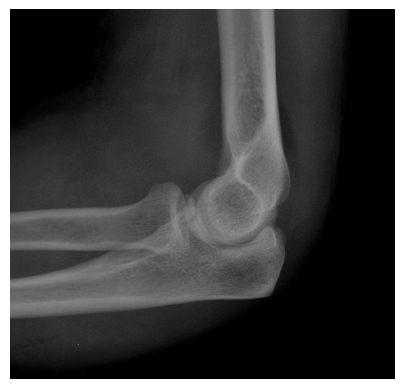

In [9]:
img = Image.open(f"BoneData/BoneFractureYolo8/valid/images/{fn}")

plt.imshow(img)
plt.axis('off')
plt.show()

In [31]:
# Step 1: open the image file
img = Image.open(f"BoneData/BoneFractureYolo8/valid/images/{fn}")
# img is a PIL Image object — not numbers yet

# Step 2: make sure it's RGB (some images are grayscale or RGBA)
img = img.convert("RGB")

# Step 3: resize to the size the model was trained on
img = img.resize((224, 224))

# Step 4: turn the PIL Image into a numpy array of pixel values
img = np.asarray(img)
# Now shape is (224, 224, 3), values 0–255 as uint8

# Step 5: normalize to 0–1 floats (must match what training used!)
img = img.astype(np.float32) / 255.0
# Same shape, but values now between 0.0 and 1.0

# Step 6: add a batch dimension — model expects (batch, H, W, 3)
img = img.reshape(1, 224, 224, 3)
# Shape is now (1, 224, 224, 3) — "batch of one image"

# Step 7: predict
prediction = model.predict(img)
# prediction shape is (1, 8) — one image, 8 outputs
pred = prediction[0]   # drop the batch dim → shape (8,)
output=np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [33]:
names=['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


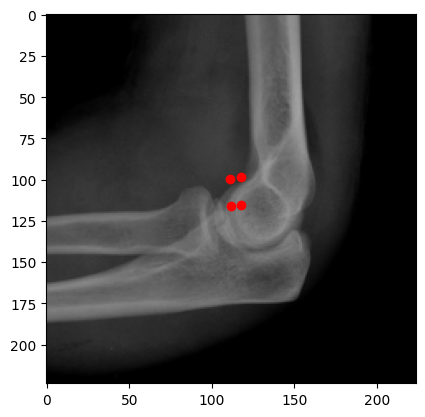

[np.float32(117.66446), np.float32(98.399376), np.float32(110.97336), np.float32(99.76457), np.float32(111.32648), np.float32(116.013695), np.float32(117.72673), np.float32(115.576996)]


In [60]:
IMG_SIZE = 224

model = keras.models.load_model("bone_fracture_model.keras")

# Load one image
img_folder = "BoneData/BoneFractureYolo8/valid/images"
fn = os.listdir(img_folder)[0]
img = Image.open(os.path.join(img_folder, fn)).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
img = np.asarray(img) / 255.0

# Predict (model needs a batch, so wrap the single image in a batch of 1)
img_batch = np.expand_dims(img, axis=0)   # shape (224, 224, 3) -> (1, 224, 224, 3) thats what expand_dims does
prediction = model.predict(img_batch)     # shape (1, 8)
pred = prediction[0]                      # shape (8,) -- pull the one result out of the batch

# Plot
plt.imshow(img)
model_coord=[]
for i in range(0, 8, 2):
    x = pred[i] * IMG_SIZE
    y = pred[i+1] * IMG_SIZE
    plt.plot(x, y, "ro")
    model_coord.append(x)
    model_coord.append(y)
plt.show()
print(model_coord)

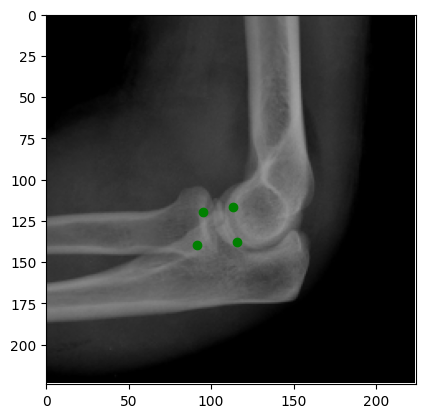

In [61]:
import matplotlib.pyplot as plt

IMG_SIZE = 224

img_folder = "BoneData/BoneFractureYolo8/valid/images"
fn = os.listdir(img_folder)[0]
img = Image.open(os.path.join(img_folder, fn)).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
img = np.asarray(img) / 255.0

# Class id, then 8 coords
parts = [0, 0.4244144458648921, 0.5335793372009953, 0.5069185316847751,
         0.5208550430372316, 0.5154337746852151, 0.6153474407357429,
         0.4075737773661954, 0.6242060783791714]

coords = parts[1:]   # drop the class id

# Plot
plt.imshow(img)
# Plot the 4 corners
for i in range(0, 8, 2): #go count by twos
    x = coords[i] * IMG_SIZE
    y = coords[i+1] * IMG_SIZE
    plt.plot(x, y, "go")

plt.xlim(0, IMG_SIZE)
plt.ylim(IMG_SIZE, 0)   # flip y so (0,0) is top-left, like an image
plt.gca().set_aspect("equal")
plt.show()

In [74]:
np_coords=np.array(coords)
np_coords=np_coords*224
np_coords

array([ 95.06883587, 119.52177153, 113.5497511 , 116.67152964,
       115.45716553, 137.83782672,  91.29652613, 139.82216156])

In [75]:
model_coord = np.array(model_coord)
model_coord

array([117.66446 ,  98.399376, 110.97336 ,  99.76457 , 111.32648 ,
       116.013695, 117.72673 , 115.576996], dtype=float32)

In [97]:
errors = []
for i in range(8):
    diff = model_coord[i] - np_coords[i]   # how far off
    errors.append(diff**2)
# squared error
new_errors =[]

for i in range(0,8,2):
    new_errors.append(np.sqrt(errors[i]+errors[i+1]))
new_errors

[np.float64(30.930855006175754),
 np.float64(17.102134732112223),
 np.float64(22.21160334569408),
 np.float64(35.86619236982892)]

In [91]:
mse = sum(new_errors) / len(new_errors)
print("MSE:", mse)

MSE: 26.527696363452748
